This notebook serves as a test to better understand zfit tools by attempting a simple gaussian fit and crystal ball fit on our data

In [1]:
import uproot
import tensorflow as tf
import zfit
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import scipy
import math

/opt/anaconda3/envs/m2_req/lib/python3.10/site-packages/zfit/__init__.py:59: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
data = zfit.Data.from_root("mu2e_caloSimu_crySpec867.root", "specTree", ["spec", "ratio", "ntrig", "stim", "time", "tErg"])
energy_unbinned = data["spec"]

#### Parameters for all data

In [3]:
cryspec = zfit.Space(['x'], limits=(0,8)) #obs range
mu_gauss = zfit.Parameter("gauss mean",5, 0,8)
sigma_gauss = zfit.Parameter("gauss width", 1,0,7)

mu_cb = zfit.Parameter("cb mean",5, 0,8)
sigma_cb = zfit.Parameter("cb width", 1,0,7)
alpha = zfit.Parameter("alpha", 2.5, 0.05, 20.0);
ndeg = zfit.Parameter ("ndeg", 10, 0.25, 80.);

In [4]:
Gauss = zfit.pdf.Gauss(obs=cryspec, mu=mu_gauss, sigma=sigma_gauss)
CrysBall = zfit.pdf.CrystalBall(obs=cryspec, mu=mu_cb, sigma=sigma_cb,n=ndeg,alpha=alpha)

#### Setting limits, scale, x & y axis

In [5]:
lower, upper = cryspec.limits
bin_count = 320
x_range= cryspec.area()

x_plot = np.linspace(lower[-1][0], upper[0][-1], num=len(energy_unbinned))

scale = (len(energy_unbinned)/bin_count)*x_range

y_plot_Gauss = (Gauss.pdf(x_plot,norm_range=cryspec))
y_plot_CrysBall= (CrysBall.pdf(x_plot,norm_range=cryspec))

Text(0.5, 0, 'E_reco [MeV]')

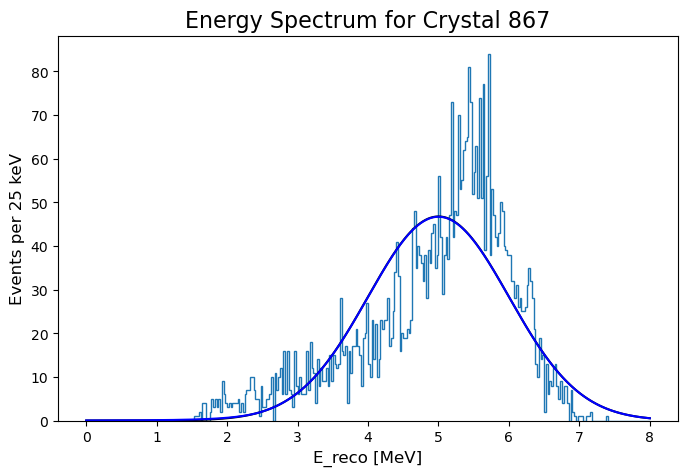

In [6]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
energy_binned, bin_location, patches = ax.hist(energy_unbinned,
                           bins=bin_count,histtype='step',
                           range=(0,8))
#x_plot_binned = np.linspace(lower[-1][0], upper[0][-1], num=len(energy_binned))
#y_plot_alldata_binned = zfit.run(alldata.pdf(x_plot_binned,norm_range=cryspec))

scale_binned = (np.sum(energy_binned)/bin_count)*x_range


plt.plot(x_plot, y_plot_Gauss*scale, color="black", label='Full Peak Gauss')
plt.plot(x_plot, y_plot_CrysBall*scale, color="blue", label='Full Peak CB')

plt.title("Energy Spectrum for Crystal 867", fontsize=16)
plt.ylabel('Events per 25 keV',fontsize=12)
plt.xlabel('E_reco [MeV]',fontsize=12)
#printing values to test what they are before and after minimisation  
#print(mu)
#print(sigma)
#print(alpha)
#print(ndeg)
# these values are evidently the ones set in the definition

#### Integral Test

In [7]:
#check to see if sum of binned data is accurate length of unbinned data
print("Sum of binned data:",np.sum(energy_binned))
print("Length of unbinned data",len(energy_unbinned))
gauss_integral = scipy.integrate.trapz(y_plot_Gauss*scale)
cb_integral = scipy.integrate.trapz(y_plot_CrysBall*scale)

print("Integral of gauss fit =",gauss_integral)
print("Integral of crystal ball fit =",cb_integral)

Sum of binned data: 4681.0
Length of unbinned data 4681
Integral of gauss fit = 68459.62477793655
Integral of crystal ball fit = 68459.62477488889


#### Create loss function, minimizer function and apply minimiser to loss function

In [8]:
nll_gauss = zfit.loss.UnbinnedNLL(model=Gauss, data=energy_unbinned)
nll_cb = zfit.loss.UnbinnedNLL(model=CrysBall, data=energy_unbinned)

minimizer = zfit.minimize.Minuit()

result_gauss = minimizer.minimize(nll_gauss, params=[mu_gauss,sigma_gauss])
result_cb = minimizer.minimize(nll_cb, params=[mu_cb,sigma_cb])

param_hesse = result_gauss.hesse()
param_hesse = result_cb.hesse()

print(result_gauss.params)
print(result_cb.params)

# these values are no longer just the ones set at the limit-- the minimisation and loss function have applied some adjustments


name           value  (rounded)        hesse    at limit
-----------  ------------------  -----------  ----------
gauss mean              4.98224  +/-   0.016       False
gauss width             1.07306  +/-   0.012       False
name        value  (rounded)        hesse    at limit
--------  ------------------  -----------  ----------
cb mean              4.99461  +/-   0.016       False
cb width              1.0523  +/-   0.012       False


#### Plot with minimized variables

Text(0.5, 0, 'E_reco [MeV]')

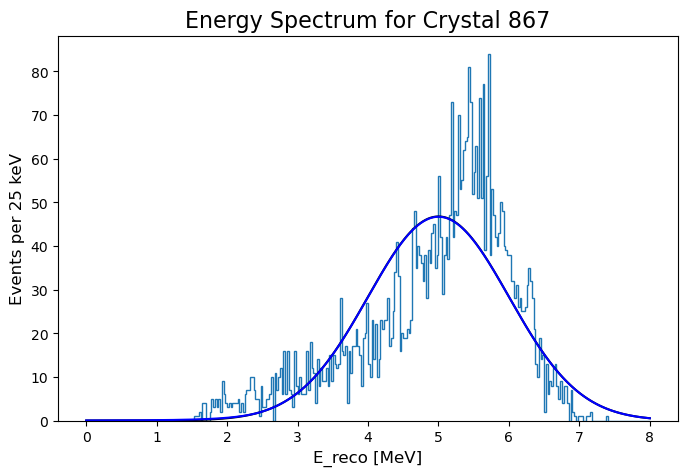

In [9]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
energy_binned, bin_location, patches = ax.hist(energy_unbinned,
                           bins=bin_count,histtype='step',
                           range=(0,8))
#x_plot_binned = np.linspace(lower[-1][0], upper[0][-1], num=len(energy_binned))

#y_plot_alldata_binned = zfit.run(alldata.pdf(x_plot_binned,norm_range=cryspec))
plt.plot(x_plot, y_plot_Gauss*scale, color="black", label='Full Peak Gauss')
plt.plot(x_plot, y_plot_CrysBall*scale, color="blue", label='Full Peak CB')
#scale_binned = (np.sum(energy_binned)/bin_count)*x_range


#plt.plot(x_plot, y_plot_alldata*scale, color="black", label='Full Peak CB')

plt.title("Energy Spectrum for Crystal 867", fontsize=16)
plt.ylabel('Events per 25 keV',fontsize=12)
plt.xlabel('E_reco [MeV]',fontsize=12)

conclusion: this format was pasted from a tutorial of zfit for the gauss function and has helped understand how to run a crystal ball function